In [2]:
import pandas as pd
from config import GLOBAL_CONFIG_DATA_RAW_LABEL_PATH

# Define the path to the CSV file
csv_file_path = GLOBAL_CONFIG_DATA_RAW_LABEL_PATH

# Load the CSV file
df = pd.read_csv(csv_file_path)

# Get the distribution of each class
class_distribution = df['class'].value_counts()

percentage_distribution = df['class'].value_counts(normalize=True)

# Display the distribution
print("Distribution of classifications:")
print(class_distribution)
print("\nPercentage distribution of classifications:")
print(percentage_distribution)

Distribution of classifications:
class
Trophozoite    15838
WBC             7004
NEG              688
Name: count, dtype: int64

Percentage distribution of classifications:
class
Trophozoite    0.673098
WBC            0.297663
NEG            0.029239
Name: proportion, dtype: float64


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from config import GLOBAL_CONFIG_RESULT_PATH

def analyze_classification_distribution(csv_path):
    """
    Analyze the distribution of classifications in the given CSV file.
    
    Parameters:
    csv_path (str): Path to the CSV file containing classification data
    
    Returns:
    dict: A dictionary with classification counts and percentages
    """
    # Read the CSV file
    df = pd.read_csv(csv_path)
    
    # Count the distribution of classifications
    class_distribution = df['class'].value_counts()
    class_percentages = df['class'].value_counts(normalize=True) * 100
    
    # Print textual distribution
    print("Classification Distribution:")
    for cls, count in class_distribution.items():
        percentage = class_percentages[cls]
        print(f"{cls}: {count} ({percentage:.2f}%)")
    
    # Visualize the distribution
    plt.figure(figsize=(10, 6))
    class_distribution.plot(kind='bar')
    plt.title('Distribution of Classifications')
    plt.xlabel('Classification')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'{GLOBAL_CONFIG_RESULT_PATH}/classification_distribution.png')
    plt.close()
    
    return {
        'counts': class_distribution.to_dict(),
        'percentages': class_percentages.to_dict()
    }

# Use the global configuration path for the CSV file
distribution_results = analyze_classification_distribution(GLOBAL_CONFIG_DATA_RAW_LABEL_PATH)

Classification Distribution:
Trophozoite: 15838 (67.31%)
WBC: 7004 (29.77%)
NEG: 688 (2.92%)


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm

def pad_image(image, target_size=(255, 255)):
    """Pad image to target size without affecting top-left coordinates."""
    h, w = image.shape[:2]
    pad_bottom = max(0, target_size[0] - h)
    pad_right = max(0, target_size[1] - w)
    
    # Create padding
    if len(image.shape) == 3:  # Color image
        padding = ((0, pad_bottom), (0, pad_right), (0, 0))
    else:  # Grayscale image
        padding = ((0, pad_bottom), (0, pad_right))
    
    # Pad with zeros (black)
    padded_image = np.pad(image, padding, mode='constant', constant_values=0)
    return padded_image

def segment_image(image, annotations, image_id, segment_size=255):
    """Segment large image into 255x255 patches and adjust box coordinates."""
    height, width = image.shape[:2]
    segments = []
    new_annotations = []
    
    # Calculate number of segments needed
    num_segments_h = (height + segment_size - 1) // segment_size
    num_segments_w = (width + segment_size - 1) // segment_size
    
    for i in range(num_segments_h):
        for j in range(num_segments_w):
            # Calculate segment coordinates
            y_start = i * segment_size
            x_start = j * segment_size
            y_end = min((i + 1) * segment_size, height)
            x_end = min((j + 1) * segment_size, width)
            
            # Extract segment
            segment = image[y_start:y_end, x_start:x_end]
            
            # Pad if necessary
            segment = pad_image(segment)
            
            # Create new image ID for segment
            new_image_id = f"{image_id.split('.')[0]}_seg_{i}_{j}.jpg"
            segments.append((new_image_id, segment))
            
            # Check each annotation if it intersects with this segment
            for annotation in annotations:
                if annotation['class'] == 'NEG':
                    # if annotation is NEG, skip
                    # # For negative samples, create one annotation per segment
                    # new_row = annotation.copy()
                    # new_row['Image_ID'] = new_image_id
                    # new_annotations.append(new_row)
                    continue
                
                original_ymin = annotation['ymin']
                original_xmin = annotation['xmin']
                original_ymax = annotation['ymax']
                original_xmax = annotation['xmax']
                
                # Check if box intersects with this segment
                if (original_xmin < x_end and original_xmax > x_start and 
                    original_ymin < y_end and original_ymax > y_start):
                    
                    # Adjust coordinates relative to segment
                    new_xmin = max(0, original_xmin - x_start)
                    new_xmax = min(segment_size, original_xmax - x_start)
                    new_ymin = max(0, original_ymin - y_start)
                    new_ymax = min(segment_size, original_ymax - y_start)
                    
                    # Create new annotation
                    new_row = annotation.copy()
                    new_row['Image_ID'] = new_image_id
                    new_row['ymin'] = new_ymin
                    new_row['xmin'] = new_xmin
                    new_row['ymax'] = new_ymax
                    new_row['xmax'] = new_xmax
                    new_annotations.append(new_row)
    
    return segments, new_annotations

def process_dataset(df, input_image_path, output_image_path, segment_size=255):
    """Process entire dataset and update CSV."""
    # Create output directory if it doesn't exist
    Path(output_image_path).mkdir(parents=True, exist_ok=True)
    
    # Group annotations by image_id
    image_groups = defaultdict(list)
    for _, row in df.iterrows():
        image_groups[row['Image_ID']].append(row.to_dict())
    
    new_annotations = []
    processed_images = set()
    
    # Process each unique image
    print("Processing images...")
    for image_id, annotations in tqdm(image_groups.items()):
        if image_id in processed_images:
            continue

        if len(annotations) == 0:
            print(f"Warning: No annotations found for image {image_id}")
            continue
            
        image_path = os.path.join(input_image_path, image_id)
        
        # Skip if image doesn't exist
        if not os.path.exists(image_path):
            print(f"Warning: Image {image_id} not found")
            continue
        
        # Read image
        image = cv2.imread(image_path)
        if image is None:
            print(f"Warning: Could not read image {image_id}")
            continue
        
        # Process image based on size
        if max(image.shape[:2]) > segment_size:
            # Segment large image
            segments, segment_annotations = segment_image(image, annotations, image_id)
            
            # Save segments
            for new_image_id, segment in segments:
                # if segment has no annotations, skip
                if len([a for a in segment_annotations if a['Image_ID'] == new_image_id]) == 0:
                    continue

                cv2.imwrite(os.path.join(output_image_path, new_image_id), segment)
            
            new_annotations.extend(segment_annotations)
            
        else:
            # Pad small image
            padded_image = pad_image(image)
            new_image_id = f"{image_id.split('.')[0]}_padded.jpg"
            cv2.imwrite(os.path.join(output_image_path, new_image_id), padded_image)
            
            # Update image ID for all annotations of this image
            for annotation in annotations:
                new_row = annotation.copy()
                new_row['Image_ID'] = new_image_id
                new_annotations.append(new_row)
        
        processed_images.add(image_id)
    
    # Create new DataFrame with updated annotations
    new_df = pd.DataFrame(new_annotations)
    return new_df

def main():
    from config import GLOBAL_CONFIG_DATA_RAW_LABEL_PATH, GLOBAL_CONFIG_DATA_RAW_IMAGE_PATH, GLOBAL_CONFIG_DATA_PATH
    GLOBAL_CONFIG_DATA_PROCESSED_IMAGE_PATH = GLOBAL_CONFIG_DATA_PATH + '/processed_images_Segmented/Images'
    GLOBAL_CONFIG_RESULT_PATH = GLOBAL_CONFIG_DATA_PATH + '/processed_images_Segmented/'
    
    print("Reading CSV file...")
    # Read the CSV file
    df = pd.read_csv(GLOBAL_CONFIG_DATA_RAW_LABEL_PATH)
    
    print(f"Found {len(df)} annotations across {df['Image_ID'].nunique()} unique images")
    
    # Process the dataset
    new_df = process_dataset(
        df,
        GLOBAL_CONFIG_DATA_RAW_IMAGE_PATH,
        GLOBAL_CONFIG_DATA_PROCESSED_IMAGE_PATH
    )
    
    # Save the updated CSV
    output_csv_path = os.path.join(GLOBAL_CONFIG_RESULT_PATH, 'processed_annotations.csv')
    new_df.to_csv(output_csv_path, index=False)
    
    print("\nProcessing complete!")
    print(f"Original annotations: {len(df)}")
    print(f"New annotations: {len(new_df)}")
    print(f"Original unique images: {df['Image_ID'].nunique()}")
    print(f"New unique images: {new_df['Image_ID'].nunique()}")
    print(f"\nNew annotations saved to {output_csv_path}")
    print(f"Processed images saved to {GLOBAL_CONFIG_DATA_PROCESSED_IMAGE_PATH}")

if __name__ == "__main__":
    main()

Reading CSV file...
Found 23530 annotations across 2747 unique images
Processing images...


100%|██████████| 2747/2747 [09:55<00:00,  4.62it/s]


Processing complete!
Original annotations: 23530
New annotations: 39164
Original unique images: 2747
New unique images: 29411

New annotations saved to ../../../Dataset//processed_images_Segmented/processed_annotations.csv
Processed images saved to ../../../Dataset//processed_images_Segmented/Images


In [6]:
# load the processed annotations
from config import GLOBAL_CONFIG_DATA_PATH
processed_annotations_path = os.path.join(GLOBAL_CONFIG_DATA_PATH, 'processed_images_Segmented/processed_annotations.csv')
processed_df = pd.read_csv(processed_annotations_path)

# Display the first few rows of the processed annotations
print("Processed Annotations:")
print(processed_df.head())

Processed Annotations:
                    Image_ID        class  confidence  ymin  xmin  ymax  xmax
0  id_u3q6jdck4j_seg_0_3.jpg          WBC         1.0   129    24   190    90
1  id_u3q6jdck4j_seg_1_5.jpg  Trophozoite         1.0   203   187   232   216
2  id_u3q6jdck4j_seg_2_4.jpg  Trophozoite         1.0   202   221   227   250
3  id_u3q6jdck4j_seg_2_5.jpg  Trophozoite         1.0   142   130   181   167
4  id_a6cl90trri_seg_0_1.jpg  Trophozoite         1.0   129   225   173   255


In [7]:
# Function to plot an image with its bounding boxes
def plot_image_with_boxes(image, boxes, YOLO_FORMAT=False, show_labels=True):
    # Get image dimensions
    h, w, _ = image.shape

    # Plot the image
    plt.figure(figsize=(10, 10))
    plt.imshow(image)

    # Plot each bounding box
    for box in boxes:
        if YOLO_FORMAT:
            class_id, x_center, y_center, width, height = box
            xmin = int((x_center - width / 2) * w)
            ymin = int((y_center - height / 2) * h)
            xmax = int((x_center + width / 2) * w)
            ymax = int((y_center + height / 2) * h)
        else:
            xmin, ymin, xmax, ymax, class_id = box

        # Draw the bounding box
        plt.gca().add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                          edgecolor='red', facecolor='none', linewidth=2))
        if show_labels:
            plt.text(xmin, ymin - 10, f'Class {int(class_id)}', color='red', fontsize=12, weight='bold')

    plt.axis('off')
    plt.show()

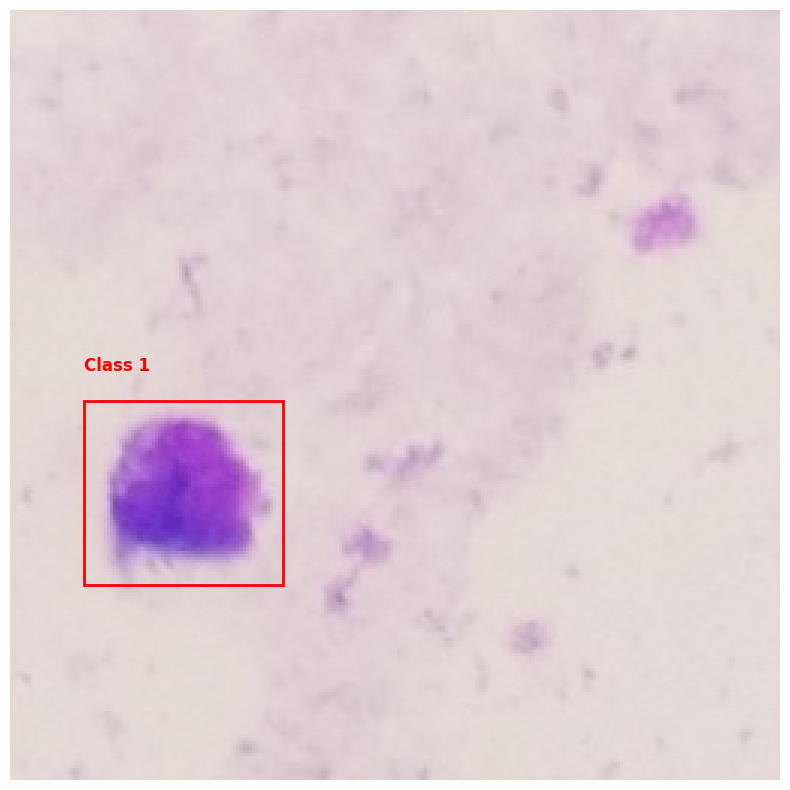

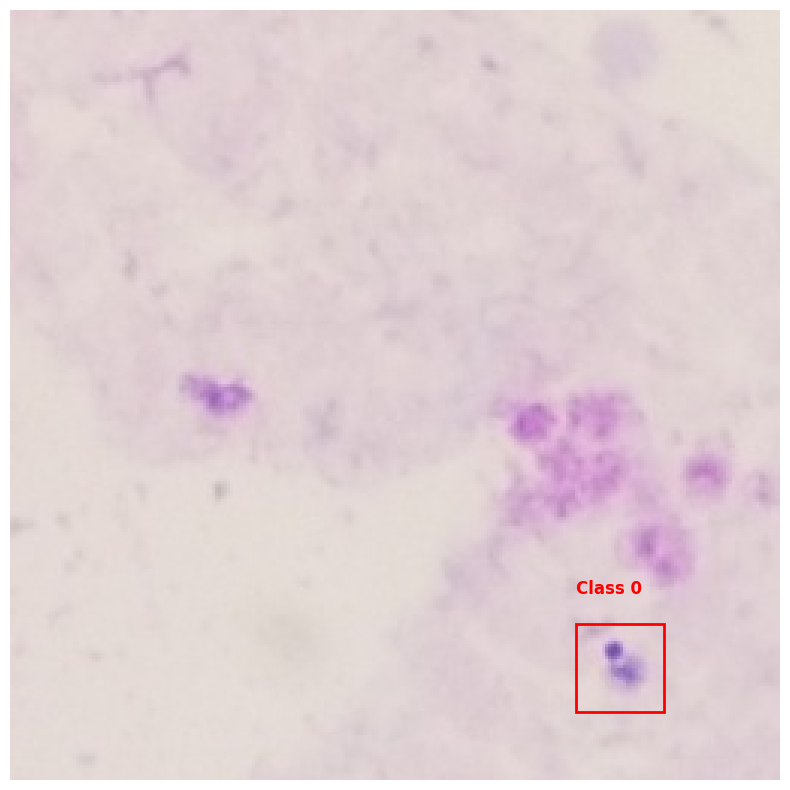

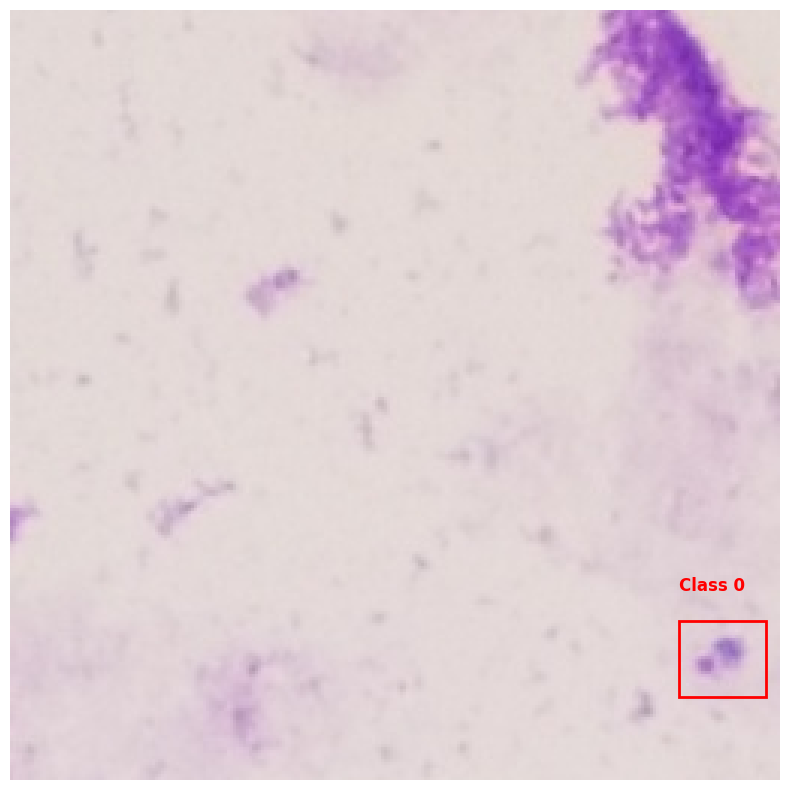

In [ ]:
# plot image with bounding boxes to check if they are correct for the first 3 images
processed_image_path = GLOBAL_CONFIG_DATA_PATH + 'processed_images_Segmented/Images'

# Get the first 3 unique image IDs
image_ids = processed_df['Image_ID'].unique()[:3]

# Load and display each image with bounding boxes
for image_id in image_ids:
    # Load image
    image_path = os.path.join(processed_image_path, image_id)
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Get bounding boxes for this image
    boxes = processed_df[processed_df['Image_ID'] == image_id][['xmin', 'ymin', 'xmax', 'ymax', 'class']].values
    
    # Update the class to be integers Trophozoite == 0, WBC == 1
    boxes[:, -1] = pd.Series(boxes[:, -1]).map({'Trophozoite': 0, 'WBC': 1}).values
    
    # Plot image with bounding boxes
    plot_image_with_boxes(image, boxes)


In [ ]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm

# Parameters
max_deviation = 10  # maximum percentage of the bounding box size that can be deviated
min_annotations_per_image = 200

# Paths
input_csv_path = GLOBAL_CONFIG_DATA_PATH + 'processed_images_Segmented/processed_annotations.csv'
output_csv_path = GLOBAL_CONFIG_DATA_PATH + 'processed_images_Segmented/augmented_annotations.csv'

# Load original annotations
df = pd.read_csv(input_csv_path)

# Function to augment a single bounding box
def augment_bbox(bbox, max_deviation, max_size=255):
    ymin, xmin, ymax, xmax = bbox

    max_x_deviation = (xmax - xmin) * max_deviation / 100
    max_y_deviation = (ymax - ymin) * max_deviation / 100

    new_ymin, new_xmin, new_ymax, new_xmax = ymin, xmin, ymax, xmax

    # Randomly select a corner and apply a deviation
    if np.random.rand() < 0.5:
        new_ymin = max(0, ymin - np.random.randint(0, max_y_deviation + 1))
    else:
        new_ymax = min(max_size, ymax + np.random.randint(0, max_y_deviation + 1))

    if np.random.rand() < 0.5:
        new_xmin = max(0, xmin - np.random.randint(0, max_x_deviation + 1))
    else:
        new_xmax = min(max_size, xmax + np.random.randint(0, max_x_deviation + 1))

    return [new_ymin, new_xmin, new_ymax, new_xmax]

# Generate augmented data
augmented_data = []

# Group annotations by Image_ID and class
grouped_df = df.groupby(['Image_ID', 'class'])

for (image_id, class_label), group in tqdm(grouped_df):
    image_annotations = group.to_dict(orient='records')

    # Repeat augmentation until we reach the desired number of annotations
    while len(image_annotations) < min_annotations_per_image:
        for annotation in group.itertuples():
            bbox = [annotation.ymin, annotation.xmin, annotation.ymax, annotation.xmax]
            new_bbox = augment_bbox(bbox, max_deviation, max_size=255)
            
            # Add augmented annotation
            image_annotations.append({
                'Image_ID': image_id,
                'class': class_label,
                'confidence': annotation.confidence,
                'ymin': new_bbox[0],
                'xmin': new_bbox[1],
                'ymax': new_bbox[2],
                'xmax': new_bbox[3]
            })
            
            # Stop if we have enough annotations
            if len(image_annotations) >= min_annotations_per_image:
                break
    
    # Append to the augmented data
    augmented_data.extend(image_annotations)

print("Augmentation complete. Augmented data generated.")

# Create a DataFrame from the augmented data
augmented_df = pd.DataFrame(augmented_data)

# save the augmented data to a CSV
# output_csv_path_initial = os.path.join(GLOBAL_CONFIG_DATA_PATH, '/processed_images_Segmented/augmented_annotations_initial.csv')
output_csv_path_initial = GLOBAL_CONFIG_DATA_PATH + 'processed_images_Segmented/augmented_annotations_initial.csv'
augmented_df.to_csv(output_csv_path_initial, index=False)

print("Augmented data saved to:", output_csv_path_initial)

# Balance classes by ensuring equal number of samples for each class
print("Balancing classes...")
class_counts = augmented_df['class'].value_counts().min()
balanced_df = augmented_df.groupby('class').sample(n=class_counts, random_state=42)

output_csv_path = GLOBAL_CONFIG_DATA_PATH + 'processed_images_Segmented/augmented_annotations.csv'

# Save to CSV
balanced_df.to_csv(output_csv_path, index=False)

print("Balanced data saved to:", output_csv_path)

print("Augmentation complete. Augmented and balanced CSV saved to:", output_csv_path)


100%|██████████| 31454/31454 [18:53<00:00, 27.75it/s]


Augmentation complete. Augmented data generated.


OSError: Cannot save file into a non-existent directory: '\processed_images_Segmented'

Distribution of classifications:
class
Trophozoite    2436800
WBC            2436800
Name: count, dtype: int64

Percentage distribution of classifications:
class
Trophozoite    50.0
WBC            50.0
Name: proportion, dtype: float64

Average class distribution per Image_ID:
class
Trophozoite    126.455631
WBC            200.000000
dtype: float64

Max class distribution per Image_ID:
class
Trophozoite    157.0
WBC            200.0
dtype: float64

Min class distribution per Image_ID:
class
Trophozoite    102.0
WBC            200.0
dtype: float64


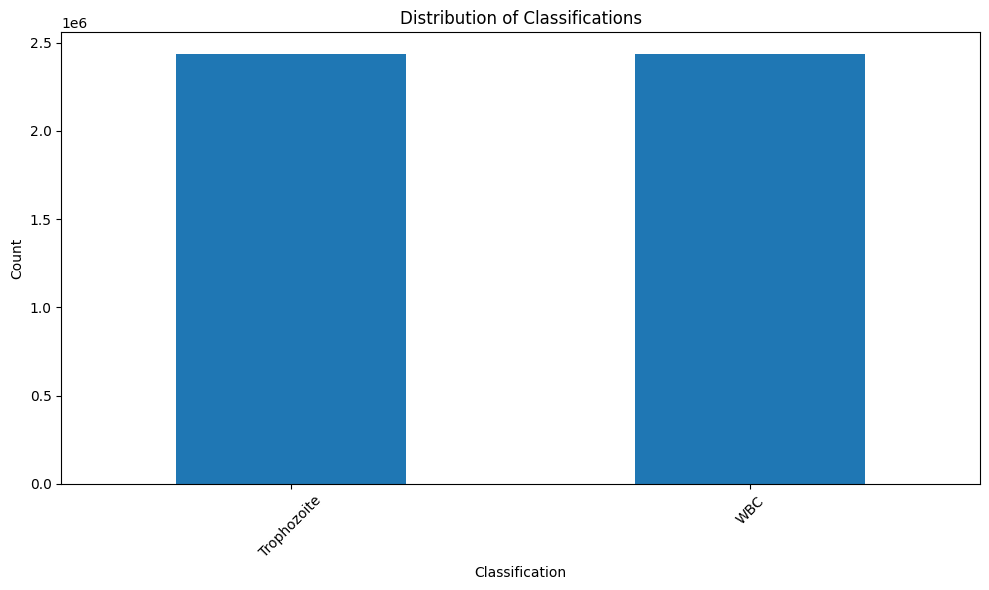

In [25]:
# Load the augmented and balanced annotations
augmented_csv_path = GLOBAL_CONFIG_DATA_PATH + 'processed_images_Segmented/augmented_annotations.csv'
augmented_df = pd.read_csv(augmented_csv_path)

# statistics of the augmented and balanced annotations
class_distribution = augmented_df['class'].value_counts()
percentage_distribution = augmented_df['class'].value_counts(normalize=True) * 100

# Display the distribution
print("Distribution of classifications:")
print(class_distribution)
print("\nPercentage distribution of classifications:")
print(percentage_distribution)

# avg class distribution per image id
avg_class_distribution = augmented_df.groupby('Image_ID')['class'].value_counts().unstack().mean()

# Display the average class distribution
print("\nAverage class distribution per Image_ID:")
print(avg_class_distribution)

# max and min class in image id
max_class_distribution = augmented_df.groupby('Image_ID')['class'].value_counts().unstack().max()
min_class_distribution = augmented_df.groupby('Image_ID')['class'].value_counts().unstack().min()

# Display the max and min class distribution
print("\nMax class distribution per Image_ID:")
print(max_class_distribution)
print("\nMin class distribution per Image_ID:")
print(min_class_distribution)

# Visualize the distribution
plt.figure(figsize=(10, 6))
class_distribution.plot(kind='bar')
plt.title('Distribution of Classifications')
plt.xlabel('Classification')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
# drop labels from the balanced annotations such that there are exactly 100 annotations per image

# Parameters
max_annotations_per_image = 100

# Group annotations by Image_ID
grouped_df = augmented_df.groupby('Image_ID')

# Drop annotations until we reach the desired number of annotations
final_data = []

for _, group in tqdm(grouped_df):
    # Get the first 100 annotations
    group = group.head(max_annotations_per_image)
    final_data.append(group)

# Create a DataFrame from the final data
final_df = pd.concat(final_data)

# Save to CSV
final_csv_path = GLOBAL_CONFIG_DATA_PATH + 'processed_images_Segmented/final_annotations.csv'
final_df.to_csv(final_csv_path, index=False)

print("Final data saved to:", final_csv_path)

100%|██████████| 29411/29411 [00:01<00:00, 15843.14it/s]


Final data saved to: ../../../Dataset/processed_images_Segmented/final_annotations.csv
